# Notebook 2: Feature Engineering
**Customer Churn & Revenue Risk Analytics Platform**

**Goal:** Transform the cleaned Telco dataset into a model-ready feature matrix.

We use the EDA findings to guide every decision here:
- Contract type was the strongest predictor → encode carefully
- Electronic check payment → flag it
- Customers without security/support services churn more → count services
- Tenure and monthly charges are key → build CLV and derived features
- Gender showed no signal → we'll confirm and note it


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('Libraries loaded.')

Libraries loaded.


## 1. Load Cleaned Data

In [2]:
df = pd.read_csv('../data/processed/telco_cleaned.csv')

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head(3)

Shape: (7043, 23)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'Churn_Binary', 'clv_estimate']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Binary,clv_estimate
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0,29.85
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.50,No,0,1936.30
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,107.70


## 2. Encode Target Variable

In [3]:
# Churn_Binary was already created in EDA notebook
# If loading fresh, re-encode here as a safety measure
if 'Churn_Binary' not in df.columns:
    df['Churn_Binary'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(f'Target distribution:')
print(df['Churn_Binary'].value_counts())
print(f'Churn rate: {df["Churn_Binary"].mean():.1%}')

Target distribution:
Churn_Binary
0    5174
1    1869
Name: count, dtype: int64
Churn rate: 26.5%


## 3. Encode Binary Yes/No Columns

Many columns are just Yes/No. We map them to 1/0 directly — no need for one-hot encoding.

In [4]:
binary_yes_no = [
    'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling'
]

for col in binary_yes_no:
    df[col] = df[col].map({'Yes': 1, 'No': 0})
    print(f'{col}: {df[col].unique()}')

# Gender: Female=1, Male=0
df['gender'] = df['gender'].map({'Female': 1, 'Male': 0})
print(f'gender: {df["gender"].unique()}')

# SeniorCitizen is already 0/1
print(f'SeniorCitizen: {df["SeniorCitizen"].unique()} (already numeric)')

Partner: [1 0]
Dependents: [0 1]
PhoneService: [0 1]
PaperlessBilling: [1 0]
gender: [1 0]
SeniorCitizen: [0 1] (already numeric)


## 4. Encode Service Columns

Service columns have three values: Yes, No, and "No internet/phone service".
We treat "No internet service" the same as No — the customer doesn't have the service.

In [5]:
service_cols = [
    'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]

for col in service_cols:
    df[col] = df[col].map({
        'Yes': 1,
        'No': 0,
        'No internet service': 0,
        'No phone service': 0
    })
    print(f'{col}: {df[col].unique()}')

MultipleLines: [0 1]
OnlineSecurity: [0 1]
OnlineBackup: [1 0]
DeviceProtection: [0 1]
TechSupport: [0 1]
StreamingTV: [0 1]
StreamingMovies: [0 1]


## 5. One-Hot Encode Multi-Class Columns

Contract, InternetService, and PaymentMethod have 3+ categories — we one-hot encode these.

In [6]:
# Before encoding, show value counts
for col in ['Contract', 'InternetService', 'PaymentMethod']:
    print(f'\n{col}:')
    print(df[col].value_counts())


Contract:
Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

InternetService:
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

PaymentMethod:
PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64


In [7]:
df = pd.get_dummies(df, columns=['Contract', 'InternetService', 'PaymentMethod'], drop_first=False)

# Show the new columns created
new_cols = [c for c in df.columns if any(x in c for x in ['Contract_', 'InternetService_', 'PaymentMethod_'])]
print('New one-hot encoded columns:')
for c in new_cols:
    print(f'  {c}')

print(f'\nShape after encoding: {df.shape}')

New one-hot encoded columns:
  Contract_Month-to-month
  Contract_One year
  Contract_Two year
  InternetService_DSL
  InternetService_Fiber optic
  InternetService_No
  PaymentMethod_Bank transfer (automatic)
  PaymentMethod_Credit card (automatic)
  PaymentMethod_Electronic check
  PaymentMethod_Mailed check

Shape after encoding: (7043, 30)


## 6. Engineer New Features

This is where we go beyond the raw data. Each feature below was motivated by an EDA finding.

In [8]:
# ── Feature 1: Customer Lifetime Value (CLV) estimate ────────────────────────
# MonthlyCharges × tenure = total revenue this customer has generated
# Motivated by: tenure and charges are both individually correlated with churn
df['clv_estimate'] = df['MonthlyCharges'] * df['tenure']

print('CLV estimate stats:')
print(df['clv_estimate'].describe().round(2))

CLV estimate stats:
count    7043.00
mean     2279.58
std      2264.73
min         0.00
25%       394.00
50%      1393.60
75%      3786.10
max      8550.00
Name: clv_estimate, dtype: float64


In [9]:
# ── Feature 2: Services count ─────────────────────────────────────────────────
# Count how many add-on services the customer subscribes to
# Motivated by: EDA showed customers WITHOUT services churn at ~40%
# More services = more embedded = more loyal
service_cols_encoded = [
    'PhoneService', 'MultipleLines', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies'
]
df['services_count'] = df[service_cols_encoded].sum(axis=1)

print('Services count distribution:')
print(df['services_count'].value_counts().sort_index())

Services count distribution:
services_count
0      80
1    1701
2    1188
3     965
4     922
5     908
6     676
7     395
8     208
Name: count, dtype: int64


In [10]:
# ── Feature 3: Charge per service ────────────────────────────────────────────
# Monthly charge divided by number of services
# High charge per service = poor perceived value = churn risk
df['charge_per_service'] = df['MonthlyCharges'] / df['services_count'].replace(0, 1)

print('Charge per service stats:')
print(df['charge_per_service'].describe().round(2))

Charge per service stats:
count    7043.00
mean       22.51
std        11.58
min        10.42
25%        15.70
50%        19.75
75%        24.52
max        72.25
Name: charge_per_service, dtype: float64


In [11]:
# ── Feature 4: Is month-to-month contract ────────────────────────────────────
# Binary flag — EDA showed this is the single strongest predictor
# 42.7% churn vs 2.8% for two-year
df['is_month_to_month'] = df['Contract_Month-to-month'].astype(int)

print(f'Month-to-month customers: {df["is_month_to_month"].sum():,}')
print(f'Churn rate (month-to-month): {df[df["is_month_to_month"]==1]["Churn_Binary"].mean():.1%}')
print(f'Churn rate (other):          {df[df["is_month_to_month"]==0]["Churn_Binary"].mean():.1%}')

Month-to-month customers: 3,875
Churn rate (month-to-month): 42.7%
Churn rate (other):          6.8%


In [12]:
# ── Feature 5: Electronic check payment flag ──────────────────────────────────
# EDA showed electronic check customers churn at ~45%
# Automatic payment customers are far more retained
df['is_electronic_check'] = (df['PaymentMethod_Electronic check'] == 1).astype(int)

print(f'Electronic check customers: {df["is_electronic_check"].sum():,}')
print(f'Churn rate (electronic check): {df[df["is_electronic_check"]==1]["Churn_Binary"].mean():.1%}')
print(f'Churn rate (other payment):    {df[df["is_electronic_check"]==0]["Churn_Binary"].mean():.1%}')

Electronic check customers: 2,365
Churn rate (electronic check): 45.3%
Churn rate (other payment):    17.1%


In [13]:
# ── Feature 6: Tenure segment ─────────────────────────────────────────────────
# Bin tenure into lifecycle stages
# New customers are highest churn risk
df['tenure_segment'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, float('inf')],
    labels=['new', 'developing', 'established', 'loyal'],
    include_lowest=True
)

print('Churn rate by tenure segment:')
print(df.groupby('tenure_segment')['Churn_Binary'].agg(['mean', 'count']).round(3))

Churn rate by tenure segment:
                 mean  count
tenure_segment              
new             0.474   2186
developing      0.287   1024
established     0.204   1594
loyal           0.095   2239


In [14]:
# ── Feature 7: Has no protection services (vulnerability flag) ────────────────
# Customers with zero security/support services are high churn risk
protection_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport']
df['no_protection_services'] = (df[protection_cols].sum(axis=1) == 0).astype(int)

print(f'Customers with no protection services: {df["no_protection_services"].sum():,}')
print(f'Churn rate (no protection): {df[df["no_protection_services"]==1]["Churn_Binary"].mean():.1%}')
print(f'Churn rate (has protection): {df[df["no_protection_services"]==0]["Churn_Binary"].mean():.1%}')

Customers with no protection services: 2,793
Churn rate (no protection): 29.8%
Churn rate (has protection): 24.4%


## 7. Validate All Engineered Features

In [15]:
engineered = [
    'clv_estimate', 'services_count', 'charge_per_service',
    'is_month_to_month', 'is_electronic_check',
    'no_protection_services'
]

print('Engineered feature summary:')
print(df[engineered].describe().round(2))

print('\nMissing values in engineered features:')
print(df[engineered].isnull().sum())

Engineered feature summary:
       clv_estimate  services_count  charge_per_service  is_month_to_month  \
count       7043.00         7043.00             7043.00            7043.00   
mean        2279.58            3.36               22.51               0.55   
std         2264.73            2.06               11.58               0.50   
min            0.00            0.00               10.42               0.00   
25%          394.00            1.00               15.70               0.00   
50%         1393.60            3.00               19.75               1.00   
75%         3786.10            5.00               24.52               1.00   
max         8550.00            8.00               72.25               1.00   

       is_electronic_check  no_protection_services  
count              7043.00                 7043.00  
mean                  0.34                    0.40  
std                   0.47                    0.49  
min                   0.00                    0.00  
25% 

## 8. Visualize Engineered Features vs Churn

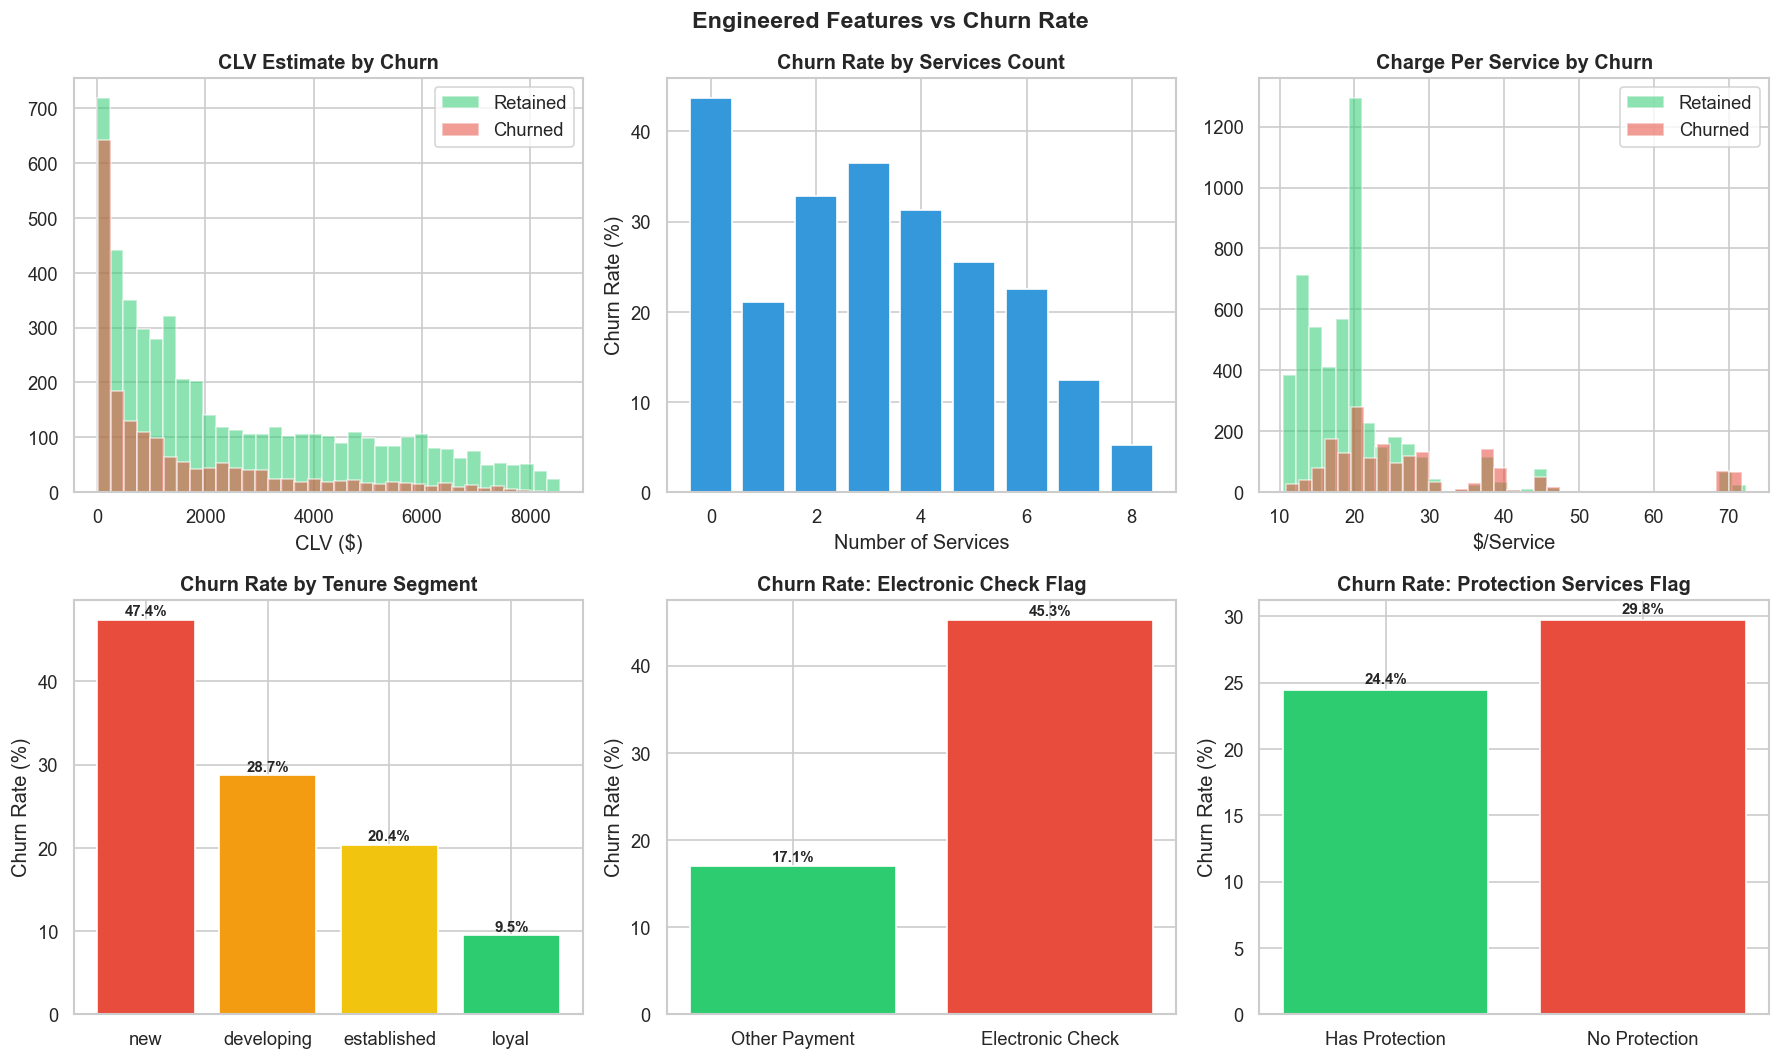

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# CLV by churn
for label, color, group in [('Retained', '#2ecc71', df[df['Churn_Binary']==0]),
                              ('Churned',  '#e74c3c', df[df['Churn_Binary']==1])]:
    axes[0,0].hist(group['clv_estimate'], bins=35, alpha=0.55, color=color, label=label)
axes[0,0].set_title('CLV Estimate by Churn', fontweight='bold')
axes[0,0].set_xlabel('CLV ($)')
axes[0,0].legend()

# Services count vs churn rate
svc_churn = df.groupby('services_count')['Churn_Binary'].mean() * 100
axes[0,1].bar(svc_churn.index, svc_churn.values, color='#3498db', edgecolor='white')
axes[0,1].set_title('Churn Rate by Services Count', fontweight='bold')
axes[0,1].set_xlabel('Number of Services')
axes[0,1].set_ylabel('Churn Rate (%)')

# Charge per service by churn
for label, color, group in [('Retained', '#2ecc71', df[df['Churn_Binary']==0]),
                              ('Churned',  '#e74c3c', df[df['Churn_Binary']==1])]:
    axes[0,2].hist(group['charge_per_service'], bins=35, alpha=0.55, color=color, label=label)
axes[0,2].set_title('Charge Per Service by Churn', fontweight='bold')
axes[0,2].set_xlabel('$/Service')
axes[0,2].legend()

# Tenure segment churn rate
seg_churn = df.groupby('tenure_segment', observed=True)['Churn_Binary'].mean() * 100
axes[1,0].bar(seg_churn.index, seg_churn.values,
              color=['#e74c3c', '#f39c12', '#f1c40f', '#2ecc71'], edgecolor='white')
axes[1,0].set_title('Churn Rate by Tenure Segment', fontweight='bold')
axes[1,0].set_ylabel('Churn Rate (%)')
for i, v in enumerate(seg_churn.values):
    axes[1,0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')

# Electronic check vs churn
ec_churn = df.groupby('is_electronic_check')['Churn_Binary'].mean() * 100
axes[1,1].bar(['Other Payment', 'Electronic Check'], ec_churn.values,
               color=['#2ecc71', '#e74c3c'], edgecolor='white')
axes[1,1].set_title('Churn Rate: Electronic Check Flag', fontweight='bold')
axes[1,1].set_ylabel('Churn Rate (%)')
for i, v in enumerate(ec_churn.values):
    axes[1,1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')

# No protection services vs churn
np_churn = df.groupby('no_protection_services')['Churn_Binary'].mean() * 100
axes[1,2].bar(['Has Protection', 'No Protection'], np_churn.values,
               color=['#2ecc71', '#e74c3c'], edgecolor='white')
axes[1,2].set_title('Churn Rate: Protection Services Flag', fontweight='bold')
axes[1,2].set_ylabel('Churn Rate (%)')
for i, v in enumerate(np_churn.values):
    axes[1,2].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Engineered Features vs Churn Rate', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/09_engineered_features.png', bbox_inches='tight')
plt.show()

## 9. Build Final Model-Ready Feature Matrix

In [17]:
# Drop columns we won't use in modeling:
# - customerID: identifier, not a feature
# - Churn: raw string target (we use Churn_Binary)
# - tenure_segment: categorical label, already captured numerically
drop_cols = ['customerID', 'Churn', 'tenure_segment']
drop_cols = [c for c in drop_cols if c in df.columns]

df_model = df.drop(columns=drop_cols)

# Convert any remaining bool columns to int
bool_cols = df_model.select_dtypes(include='bool').columns
df_model[bool_cols] = df_model[bool_cols].astype(int)

print(f'Final model feature matrix shape: {df_model.shape}')
print(f'\nAll columns ({len(df_model.columns)}):')
for col in df_model.columns:
    print(f'  {col} — dtype: {df_model[col].dtype}')

Final model feature matrix shape: (7043, 33)

All columns (33):
  gender — dtype: int64
  SeniorCitizen — dtype: int64
  Partner — dtype: int64
  Dependents — dtype: int64
  tenure — dtype: int64
  PhoneService — dtype: int64
  MultipleLines — dtype: int64
  OnlineSecurity — dtype: int64
  OnlineBackup — dtype: int64
  DeviceProtection — dtype: int64
  TechSupport — dtype: int64
  StreamingTV — dtype: int64
  StreamingMovies — dtype: int64
  PaperlessBilling — dtype: int64
  MonthlyCharges — dtype: float64
  TotalCharges — dtype: float64
  Churn_Binary — dtype: int64
  clv_estimate — dtype: float64
  Contract_Month-to-month — dtype: int64
  Contract_One year — dtype: int64
  Contract_Two year — dtype: int64
  InternetService_DSL — dtype: int64
  InternetService_Fiber optic — dtype: int64
  InternetService_No — dtype: int64
  PaymentMethod_Bank transfer (automatic) — dtype: int64
  PaymentMethod_Credit card (automatic) — dtype: int64
  PaymentMethod_Electronic check — dtype: int64
  Pay

In [18]:
# Final check — no nulls, all numeric
print('Missing values:')
print(df_model.isnull().sum()[df_model.isnull().sum() > 0])

non_numeric = df_model.select_dtypes(exclude=['int64', 'float64', 'int32', 'uint8']).columns.tolist()
if non_numeric:
    print(f'\nNon-numeric columns remaining: {non_numeric}')
else:
    print('\nAll columns are numeric. Ready for modeling.')

Missing values:
Series([], dtype: int64)

All columns are numeric. Ready for modeling.


In [19]:
# Save for Notebook 3
df_model.to_csv('../data/processed/telco_features.csv', index=False)
print('Saved: data/processed/telco_features.csv')
print(f'Shape: {df_model.shape}')
print('\nReady for Notebook 3: Model Training')

Saved: data/processed/telco_features.csv
Shape: (7043, 33)

Ready for Notebook 3: Model Training


## Summary

| Feature | Type | Motivation from EDA |
|---|---|---|
| `clv_estimate` | Engineered | MonthlyCharges × tenure — captures total revenue generated |
| `services_count` | Engineered | More services = more embedded = lower churn |
| `charge_per_service` | Engineered | High cost per service signals poor perceived value |
| `is_month_to_month` | Engineered | 42.7% churn — strongest single predictor |
| `is_electronic_check` | Engineered | ~45% churn vs ~16% for automatic payment |
| `no_protection_services` | Engineered | Customers without security/support churn at ~40% |
| Contract, InternetService, PaymentMethod | One-hot encoded | Multi-class categoricals |
| gender, Partner, Dependents, etc. | Binary encoded | Yes/No fields mapped to 1/0 |